In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Path to the CSV file (adjust the path based on where your file is in Google Drive)
file_path = '/content/drive/My Drive/ProjectBigData/01 datasets/mas_charges.csv'
file_path1 = '/content/drive/My Drive/ProjectBigData/01 datasets/sal_charges.csv'


# Read the CSV file into a DataFrame
mas_df = pd.read_csv(file_path, header = 2, encoding = "ISO-8859-1")
sal_df = pd.read_csv(file_path1, header = 2, encoding = "ISO-8859-1")

In [ ]:
pd.set_option('display.max_columns', None)

# JOINING THE DATASETS

In [ ]:
mas_data1 = mas_df.copy()
mas_data1["location"] = "Massachusetts"

sal_data1 = sal_df.copy()
sal_data1["location"] = "Salem"

merged_df = pd.concat([mas_data1, sal_data1])
merged_df.shape

(10166340, 26)

# DROPPING COLUMNS WITH HIGH MISSING VALUES

In [ ]:
missing_ratio = merged_df.isnull().sum()/merged_df.shape[0]
high_missing_cols = missing_ratio[missing_ratio > 0.5].index.tolist()
len(high_missing_cols)

13

In [ ]:
merged_df = merged_df.drop(columns = high_missing_cols)
merged_df.shape

(10166340, 13)

# DROPPING CODE 3 VARIABLE AS IT HAS NO VARIANCE

In [ ]:
merged_df = merged_df.drop(columns = ["code|3|type"])

In [ ]:
merged_df.shape

(10166340, 12)

In [ ]:
merged_df.head()

,description,code|1,code|1|type,code|2,code|2|type,code|3,setting,standard_charge|gross,standard_charge|discounted_cash,payer_name,plan_name,location
0,Embolect Art Fem/Pop/Aortoiliac Abd,PX-76000853,CDM,34201,CPT,361.0,outpatient,24541.0,18405.75,TRICARE [160005],TRICARE SOUTH REGION [16000502],Massachusetts
1,Repair Aneur Aorto-Bi-Iliac Prosth,PX-76000876,CDM,34831,CPT,361.0,outpatient,47638.0,35728.50,FALLON HEALTH [1008],FALLON MEDICARE REPLACEMENT [100803],Massachusetts
2,Dress/Debride Burn >10% Total Large,PX-76000207,CDM,16030,CPT,761.0,outpatient,870.0,652.50,FALLON HEALTH [1008],FALLON MEDICARE REPLACEMENT [100803],Massachusetts
3,STAPLE COMPRESSION 15X15MM OSSIOFIBER,SUP-682499,CDM,C1713,HCPCS,278.0,inpatient,4491.0,3368.25,GENERIC MEDICARE REPLACEMENT [1010],MASS ADVANTAGE UMASS MEM MEDICARE REPLACEMENT ...,Massachusetts
4,INTRODUCER DI LOCK 9FR 14CM .038IN GUIDING DIL...,SUP-45184,CDM,C1892,HCPCS,272.0,inpatient,84.0,63.00,MGB HEALTH PLAN [150001],MGBHP EMPLOYEES FAMILY [15000110],Massachusetts


In [ ]:
merged_df["description"].nunique()

24898

In [ ]:
merged_df.isnull().sum()

,0
description,0
code|1,0
code|1|type,0
code|2,622417
code|2|type,622417
code|3,296911
setting,0
standard_charge|gross,915
standard_charge|discounted_cash,451803
payer_name,0


# SEPARATE TRAIN AND TEST DATA (CONTAINS MISSING TARGET)

In [ ]:
df_train = merged_df[merged_df["standard_charge|discounted_cash"].notnull()]
df_missing = merged_df[merged_df["standard_charge|discounted_cash"].isnull()] #test

In [ ]:
df_train.shape

(9714537, 12)

In [ ]:
df_missing.shape

(451803, 12)

In [ ]:
df_train.isnull().sum()

,0
description,0
code|1,0
code|1|type,0
code|2,621687
code|2|type,621687
code|3,296911
setting,0
standard_charge|gross,0
standard_charge|discounted_cash,0
payer_name,0


As per documentation, if no code type is present, we can use LOCAL in its place

In [ ]:
code_2_local = df_train.loc[df_train["code|2|type"] == "LOCAL","code|2"].mode().values[0]
code_3_local = df_train.loc[df_train["code|2|type"] == "LOCAL","code|3"].mode().values[0]

In [ ]:
df_train.loc[df_train["code|2|type"].isnull(), "code|2|type"] = "LOCAL"
df_train.loc[df_train["code|2"].isnull(), "code|2"] = code_2_local
df_train.loc[df_train["code|3"].isnull(), "code|3"] = code_3_local

In [ ]:
df_train.isnull().sum()

,0
description,0
code|1,0
code|1|type,0
code|2,0
code|2|type,0
code|3,0
setting,0
standard_charge|gross,0
standard_charge|discounted_cash,0
payer_name,0


In [ ]:
df_train.shape

(9714537, 12)

In [ ]:
df_train.head()

,description,code|1,code|1|type,code|2,code|2|type,code|3,setting,standard_charge|gross,standard_charge|discounted_cash,payer_name,plan_name,location
0,Embolect Art Fem/Pop/Aortoiliac Abd,PX-76000853,CDM,34201,CPT,361.0,outpatient,24541.0,18405.75,TRICARE [160005],TRICARE SOUTH REGION [16000502],Massachusetts
1,Repair Aneur Aorto-Bi-Iliac Prosth,PX-76000876,CDM,34831,CPT,361.0,outpatient,47638.0,35728.50,FALLON HEALTH [1008],FALLON MEDICARE REPLACEMENT [100803],Massachusetts
2,Dress/Debride Burn >10% Total Large,PX-76000207,CDM,16030,CPT,761.0,outpatient,870.0,652.50,FALLON HEALTH [1008],FALLON MEDICARE REPLACEMENT [100803],Massachusetts
3,STAPLE COMPRESSION 15X15MM OSSIOFIBER,SUP-682499,CDM,C1713,HCPCS,278.0,inpatient,4491.0,3368.25,GENERIC MEDICARE REPLACEMENT [1010],MASS ADVANTAGE UMASS MEM MEDICARE REPLACEMENT ...,Massachusetts
4,INTRODUCER DI LOCK 9FR 14CM .038IN GUIDING DIL...,SUP-45184,CDM,C1892,HCPCS,272.0,inpatient,84.0,63.00,MGB HEALTH PLAN [150001],MGBHP EMPLOYEES FAMILY [15000110],Massachusetts


In [ ]:
# checking description overlap between train and test
train_desc = set(df_train["description"].dropna().unique())
missing_desc = set(df_missing["description"].dropna().unique())

common_desc = train_desc.intersection(missing_desc)
len(common_desc)
new_desc = missing_desc.difference(train_desc)
len(new_desc)
overlap_pct = len(common_desc) / len(missing_desc) * 100
print(f"{overlap_pct:.2f}% of missing descriptions already exist in training data.")

98.68% of missing descriptions already exist in training data.


In [ ]:
# checking description overlap between train and test
train_desc = set(df_train["code|1"].dropna().unique())
missing_desc = set(df_missing["code|1"].dropna().unique())

common_desc = train_desc.intersection(missing_desc)
len(common_desc)
new_desc = missing_desc.difference(train_desc)
len(new_desc)
overlap_pct = len(common_desc) / len(missing_desc) * 100
print(f"{overlap_pct:.2f}% of missing code|1 already exist in training data.")

98.77% of missing code|1 already exist in training data.


In [ ]:
# checking description overlap between train and test
train_desc = set(df_train["code|1|type"].dropna().unique())
missing_desc = set(df_missing["code|1|type"].dropna().unique())

common_desc = train_desc.intersection(missing_desc)
len(common_desc)
new_desc = missing_desc.difference(train_desc)
len(new_desc)
overlap_pct = len(common_desc) / len(missing_desc) * 100
print(f"{overlap_pct:.2f}% of missing code|1|type already exist in training data.")

100.00% of missing code|1|type already exist in training data.


In [ ]:
# checking description overlap between train and test
train_desc = set(df_train["code|2"].dropna().unique())
missing_desc = set(df_missing["code|2"].dropna().unique())

common_desc = train_desc.intersection(missing_desc)
len(common_desc)
new_desc = missing_desc.difference(train_desc)
len(new_desc)
overlap_pct = len(common_desc) / len(missing_desc) * 100
print(f"{overlap_pct:.2f}% of missing code|2 already exist in training data.")

90.82% of missing code|2 already exist in training data.


In [ ]:
# checking description overlap between train and test
train_desc = set(df_train["code|2|type"].dropna().unique())
missing_desc = set(df_missing["code|2|type"].dropna().unique())

common_desc = train_desc.intersection(missing_desc)
len(common_desc)
new_desc = missing_desc.difference(train_desc)
len(new_desc)
overlap_pct = len(common_desc) / len(missing_desc) * 100
print(f"{overlap_pct:.2f}% of missing code|2|type already exist in training data.")

100.00% of missing code|2|type already exist in training data.


In [ ]:
# checking description overlap between train and test
train_desc = set(df_train["code|3"].dropna().unique())
missing_desc = set(df_missing["code|3"].dropna().unique())

common_desc = train_desc.intersection(missing_desc)
len(common_desc)
new_desc = missing_desc.difference(train_desc)
len(new_desc)
overlap_pct = len(common_desc) / len(missing_desc) * 100
print(f"{overlap_pct:.2f}% of missing code|3 already exist in training data.")

68.29% of missing code|3 already exist in training data.


In [ ]:
df_train["code|3"].nunique(), df_missing["code|3"].nunique()

(204, 41)

In [ ]:
df_train.columns

Index(['description', 'code|1', 'code|1|type', 'code|2', 'code|2|type',
       'code|3', 'setting', 'standard_charge|gross',
       'standard_charge|discounted_cash', 'payer_name', 'plan_name',
       'location'],
      dtype='object')

# Feature Importance with Target

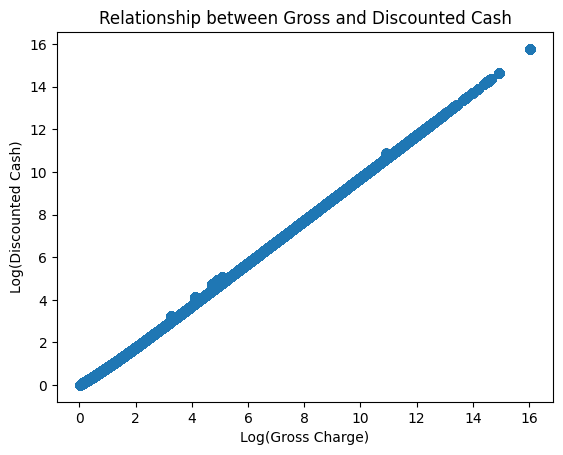

In [ ]:
import numpy as np, matplotlib.pyplot as plt

plt.scatter(np.log1p(df_train["standard_charge|gross"]),
            np.log1p(df_train["standard_charge|discounted_cash"]), alpha=0.3)
plt.xlabel("Log(Gross Charge)")
plt.ylabel("Log(Discounted Cash)")
plt.title("Relationship between Gross and Discounted Cash")
plt.show()


In [ ]:
df_train[["standard_charge|gross", "standard_charge|discounted_cash"]].corr()


,standard_charge|gross,standard_charge|discounted_cash
standard_charge|gross,1.0,1.0
standard_charge|discounted_cash,1.0,1.0


In [ ]:
df_train.dtypes

,0
description,object
code|1,object
code|1|type,object
code|2,object
code|2|type,object
code|3,float64
setting,object
standard_charge|gross,float64
standard_charge|discounted_cash,float64
payer_name,object


In [ ]:
df_train.head()

,description,code|1,code|1|type,code|2,code|2|type,code|3,setting,standard_charge|gross,standard_charge|discounted_cash,payer_name,plan_name,location
0,Embolect Art Fem/Pop/Aortoiliac Abd,PX-76000853,CDM,34201,CPT,361.0,outpatient,24541.0,18405.75,TRICARE [160005],TRICARE SOUTH REGION [16000502],Massachusetts
1,Repair Aneur Aorto-Bi-Iliac Prosth,PX-76000876,CDM,34831,CPT,361.0,outpatient,47638.0,35728.50,FALLON HEALTH [1008],FALLON MEDICARE REPLACEMENT [100803],Massachusetts
2,Dress/Debride Burn >10% Total Large,PX-76000207,CDM,16030,CPT,761.0,outpatient,870.0,652.50,FALLON HEALTH [1008],FALLON MEDICARE REPLACEMENT [100803],Massachusetts
3,STAPLE COMPRESSION 15X15MM OSSIOFIBER,SUP-682499,CDM,C1713,HCPCS,278.0,inpatient,4491.0,3368.25,GENERIC MEDICARE REPLACEMENT [1010],MASS ADVANTAGE UMASS MEM MEDICARE REPLACEMENT ...,Massachusetts
4,INTRODUCER DI LOCK 9FR 14CM .038IN GUIDING DIL...,SUP-45184,CDM,C1892,HCPCS,272.0,inpatient,84.0,63.00,MGB HEALTH PLAN [150001],MGBHP EMPLOYEES FAMILY [15000110],Massachusetts


In [ ]:
from scipy.stats import f_oneway, kruskal

# Example for 'setting'
groups = [group["standard_charge|discounted_cash"].dropna().values
          for _, group in df_train.groupby("setting")]
stat, p = f_oneway(*groups)
print("ANOVA p-value (setting):", p)


ANOVA p-value (setting): 0.0


In [ ]:
b# Example for 'setting'
groups = [group["standard_charge|discounted_cash"].dropna().values
          for _, group in df_train.groupby("code|1|type")]
stat, p = f_oneway(*groups)
print("ANOVA p-value (code|1|type	", p)


ANOVA p-value (setting): 0.0


In [ ]:
# Example for 'setting'
groups = [group["standard_charge|discounted_cash"].dropna().values
          for _, group in df_train.groupby("code|2|type")]
stat, p = f_oneway(*groups)
print("ANOVA p-value (code|1|type	", p)


ANOVA p-value (code|1|type	 0.0


In [ ]:
groups = [group["standard_charge|discounted_cash"].dropna().values
          for _, group in df_train.groupby("payer_name")]
stat, p = f_oneway(*groups)
print("ANOVA p-value of payer_name	", p)


ANOVA p-value of payer_name	 6.1161318228905724e-86


In [ ]:
groups = [group["standard_charge|discounted_cash"].dropna().values
          for _, group in df_train.groupby("payer_name")]
stat, p = f_oneway(*groups)
print("ANOVA p-value of plan_name	", p)


ANOVA p-value of plan_name	 6.1161318228905724e-86


In [ ]:
groups = [group["standard_charge|discounted_cash"].dropna().values
          for _, group in df_train.groupby("code|1")]
stat, p = f_oneway(*groups)
print("ANOVA p-value of code|1	", p)


ANOVA p-value of code|1	 0.0


In [ ]:
groups = [group["standard_charge|discounted_cash"].dropna().values
          for _, group in df_train.groupby("code|2")]
stat, p = f_oneway(*groups)
print("ANOVA p-value of code|2	", p)


ANOVA p-value of code|2	 0.0


In [ ]:
groups = [group["standard_charge|discounted_cash"].dropna().values
          for _, group in df_train.groupby("code|3")]
stat, p = f_oneway(*groups)
print("ANOVA p-value of code|3	", p)


ANOVA p-value of code|3	 0.0


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df_train['code|1'], df_train['code|1|type'])
chi2 = chi2_contingency(contingency)[0]
n = contingency.sum().sum()
r, k = contingency.shape
cramers_v = np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
print(f"Cramér's V: {cramers_v:.3f}")


Cramér's V: 1.000


Cramer’s V > 0.8, it’s highly redundant → keep only one.

In [ ]:
contingency = pd.crosstab(df_train['code|2'], df_train['code|2|type'])
chi2 = chi2_contingency(contingency)[0]
n = contingency.sum().sum()
r, k = contingency.shape
cramers_v = np.sqrt((chi2 / n) / (min(k - 1, r - 1)))
print(f"Cramér's V: {cramers_v:.3f}")


Cramér's V: 0.999
